# 03_TrainModels_p - Phát
## Train 5 classification models using sklearn

### 1. Import thư viện và tải dữ liệu đã xử lý

In [18]:
import joblib
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Tải dữ liệu đã được xử lý từ notebook 02_Processing.ipynb
X_train = joblib.load("X_train.pkl")
X_test = joblib.load("X_test.pkl")
y_train = joblib.load("y_train.pkl")
y_test = joblib.load("y_test.pkl")

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (960, 4)
X_test shape: (412, 4)
y_train shape: (960,)
y_test shape: (412,)


### 2. Khởi tạo 5 mô hình classification

In [19]:
# 5 mô hình do Phát phụ trách
model_knn = KNeighborsClassifier()
model_nb = GaussianNB()
model_svm = SVC()
model_dt = DecisionTreeClassifier(random_state=42)
model_rf = RandomForestClassifier(random_state=42)

models = {
    "KNN": model_knn,
    "NaiveBayes": model_nb,
    "SVM": model_svm,
    "DecisionTree": model_dt,
    "RandomForest": model_rf
}

print("Đã khởi tạo xong 5 mô hình.")

Đã khởi tạo xong 5 mô hình.


### 3. Huấn luyện (train) các mô hình

In [20]:
print("Training models...")

train_times = {}

for name, model in models.items():
    start = time.perf_counter()
    model.fit(X_train, y_train)
    train_times[name] = time.perf_counter() - start
    print(f"{name}: done in {train_times[name]:.4f} s")

print("Training completed!")

Training models...


KNN: done in 0.1178 s
NaiveBayes: done in 0.0289 s
SVM: done in 0.0308 s
DecisionTree: done in 0.0218 s
RandomForest: done in 0.1454 s
Training completed!


### 4. Dự đoán trên tập test

In [21]:
predictions = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    predictions[name] = y_pred
    print(f"{name}: {len(y_pred)} phần tử dự đoán trên tập test")
    print(f"  First 10: {y_pred[:10]}")

print("Prediction completed!")

KNN: 412 phần tử dự đoán trên tập test
  First 10: [0 0 0 0 0 0 0 0 0 0]
NaiveBayes: 412 phần tử dự đoán trên tập test
  First 10: [0 0 0 0 0 0 0 0 0 0]
SVM: 412 phần tử dự đoán trên tập test
  First 10: [0 0 0 0 0 0 0 0 0 0]
DecisionTree: 412 phần tử dự đoán trên tập test
  First 10: [0 0 0 0 0 0 1 0 0 0]
RandomForest: 412 phần tử dự đoán trên tập test
  First 10: [0 0 0 0 0 0 0 0 0 0]
Prediction completed!


### 5. Lưu kết quả dự đoán và mô hình

In [25]:
# Lưu dự đoán
for name, y_pred in predictions.items():
    joblib.dump(y_pred, f"results_test/{name}_pred.pkl")

# Lưu mô hình
for name, model in models.items():
    joblib.dump(model, f"results_test/{name}_model.pkl")

print("Saved predictions and models successfully!")

Saved predictions and models successfully!


### 6. Đánh giá nhanh bằng Accuracy

In [23]:
print("\nModel Accuracy:")

accuracy_results = {}
for name, model in models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracy_results[name] = acc
    print(f"{name}: {acc:.4f}")

results_df = pd.DataFrame({
    "Model": list(accuracy_results.keys()),
    "Accuracy": list(accuracy_results.values())
}).sort_values("Accuracy", ascending=False).reset_index(drop=True)

results_df


Model Accuracy:
KNN: 1.0000
NaiveBayes: 0.8374
SVM: 1.0000
DecisionTree: 0.9806
RandomForest: 0.9976


,Model,Accuracy
0,KNN,1.000000
1,SVM,1.000000
2,RandomForest,0.997573
3,DecisionTree,0.980583
4,NaiveBayes,0.837379


### 7. Confusion Matrix cho mô hình tốt nhất

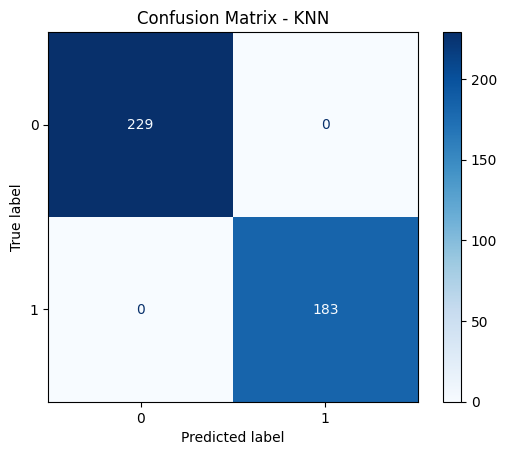

In [24]:
best_model_name = results_df.loc[0, "Model"]
best_model = models[best_model_name]
y_pred_best = predictions[best_model_name]

cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues", values_format="d")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

## Kết thúc